# 🚀 QUICK SINGLE FILE ANALYSIS

## Fast NetCDF File Analysis - Optimized for Single File Processing

This is an optimized version designed specifically for analyzing **one NetCDF file quickly** without unnecessary overhead.

**Key Optimizations:**
- ⚡ Minimal imports (only essential libraries)
- 🎯 Direct file analysis (no directory scanning)
- ⏱️ Built-in timing measurements
- 📊 Essential information only
- 🔥 Fast execution for single file purpose

In [2]:
# Cell 1: All Necessary Imports
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import sys
import os
from typing import Optional, Any
import numpy as np
import xarray as xr
# Configure matplotlib for inline plots
%matplotlib inline

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print("📊 Ready to analyze NetCDF files!")

✅ All libraries imported successfully!
📊 Ready to analyze NetCDF files!


In [3]:
# Cell 2: NetCDF File Structure Analysis
# Specify your NetCDF file path
file_path = r"C:\Users\abhik\Desktop\project related work\SWOT_L2_LR_SSH_2.0_2.0-20250822_162623\SWOT_L2_LR_SSH_Expert_008_411_20231228T222330_20231228T231406_PGC0_02.nc"

# Load the NetCDF file using xarray
ds = xr.open_dataset(file_path)

print("📂 FILE STRUCTURE ANALYSIS")
print("="*50)

# Basic file information
print(f"📁 File: {Path(file_path).name}")
print(f"📊 File size: {Path(file_path).stat().st_size / (1024*1024):.1f} MB")

# Show dimensions
print(f"\n📐 DIMENSIONS:")
for dim_name, dim_size in ds.dims.items():
    print(f"   • {dim_name}: {dim_size}")

# Show coordinates with sample values
print(f"\n📍 COORDINATES:")
for coord_name, coord_var in ds.coords.items():
    print(f"   • {coord_name}: {coord_var.shape} ({coord_var.dtype})")
    # Show sample values
    if coord_var.size > 0:
        sample = coord_var.values.flatten()[:3]  # First 3 values
        print(f"     Sample values: {sample}")

# Show data variables with sample values
print(f"\n📋 DATA VARIABLES:")
for var_name, var_data in ds.data_vars.items():
    print(f"   • {var_name}: {var_data.shape} ({var_data.dtype})")
    
    # Show attributes if available
    if var_data.attrs:
        print(f"     Description: {var_data.attrs.get('long_name', 'No description')}")
        print(f"     Units: {var_data.attrs.get('units', 'No units')}")
    
    # Show sample values for numeric variables
    if np.issubdtype(var_data.dtype, np.number) and var_data.size > 0:
        sample_flat = var_data.values.flatten()
        valid_sample = sample_flat[~np.isnan(sample_flat)][:3]  # First 3 valid values
        if len(valid_sample) > 0:
            print(f"     Sample values: {valid_sample}")
    
    print()  # Empty line for readability

# Summary
print(f"📋 SUMMARY:")
print(f"   Total Dimensions: {len(ds.dims)}")
print(f"   Total Variables: {len(ds.data_vars)}")
print(f"   Total Coordinates: {len(ds.coords)}")


📂 FILE STRUCTURE ANALYSIS
📁 File: SWOT_L2_LR_SSH_Expert_008_411_20231228T222330_20231228T231406_PGC0_02.nc
📊 File size: 32.1 MB

📐 DIMENSIONS:
   • num_lines: 9866
   • num_pixels: 69
   • num_sides: 2

📍 COORDINATES:
   • latitude: (9866, 69) (float64)
     Sample values: [-77.053701 -77.071617 -77.089532]
   • longitude: (9866, 69) (float64)
     Sample values: [8.934828 8.934569 8.934309]
   • latitude_nadir: (9866,) (float64)
     Sample values: [nan nan nan]
   • longitude_nadir: (9866,) (float64)
     Sample values: [nan nan nan]

📋 DATA VARIABLES:
   • time: (9866,) (datetime64[ns])
     Description: time in UTC
     Units: No units

   • time_tai: (9866,) (datetime64[ns])
     Description: time in TAI
     Units: No units

   • ssh_karin: (9866, 69) (float64)
     Description: sea surface height
     Units: m
     Sample values: [28.9634 28.9111 28.832 ]

   • ssh_karin_qual: (9866, 69) (float64)
     Description: quality flag for sea surface height from KaRIn
     Units: No un

🎨 BASIC DATA VISUALIZATION
📊 Visualizing: ssh_karin
   Shape: (9866, 69)
   Dimensions: ('num_lines', 'num_pixels')


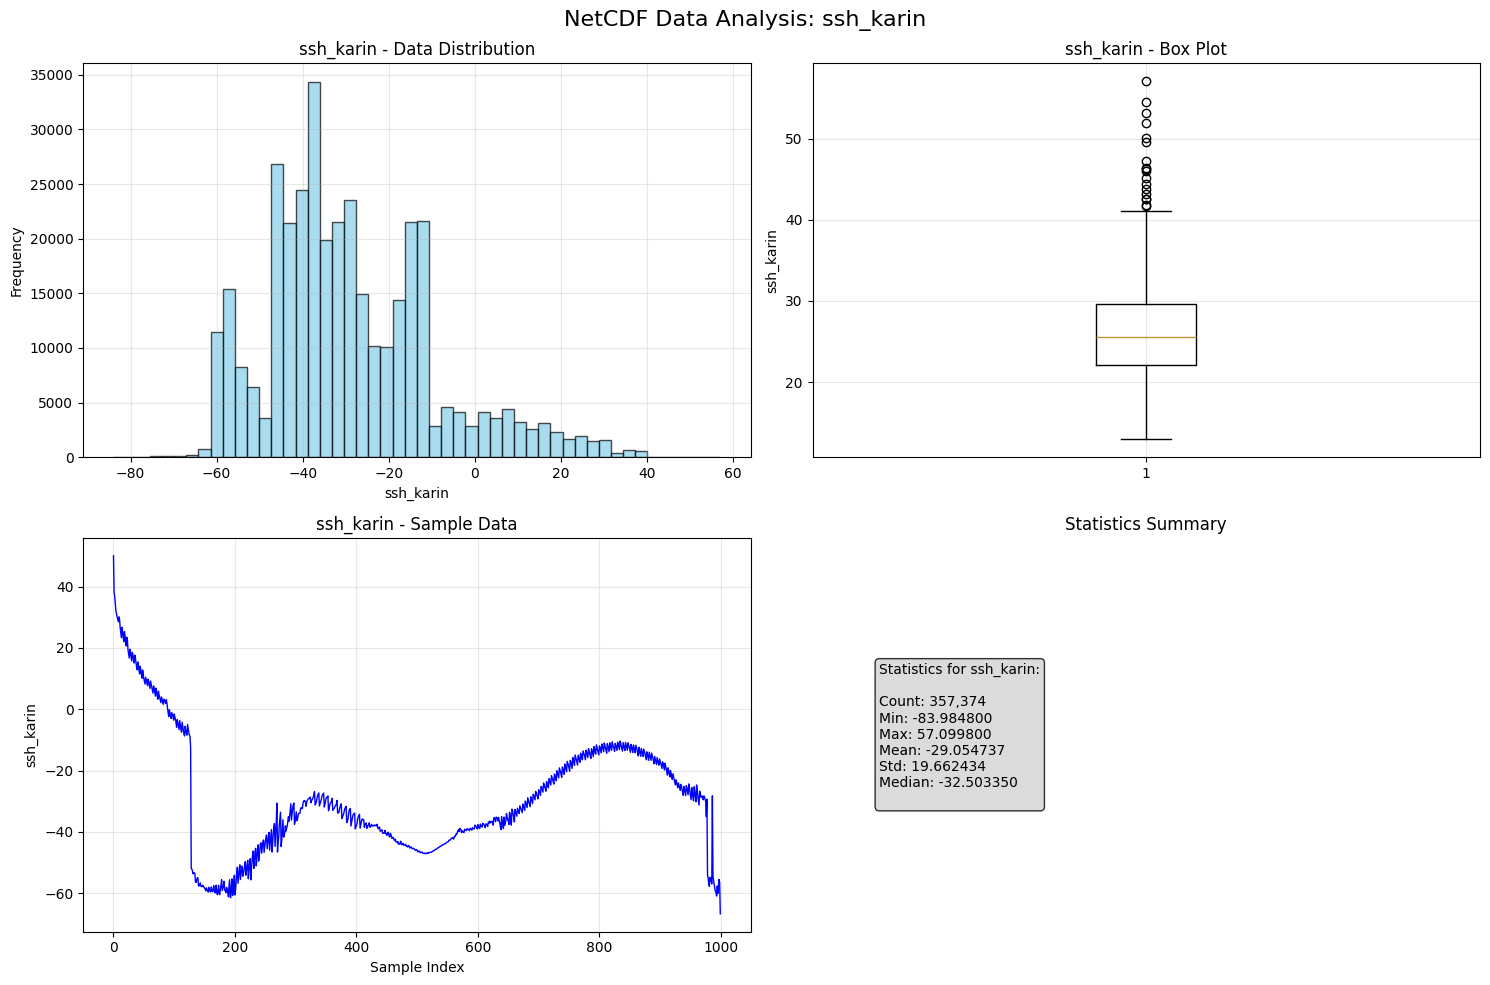

✅ Visualization complete for ssh_karin

🗺️ COORDINATE VISUALIZATION


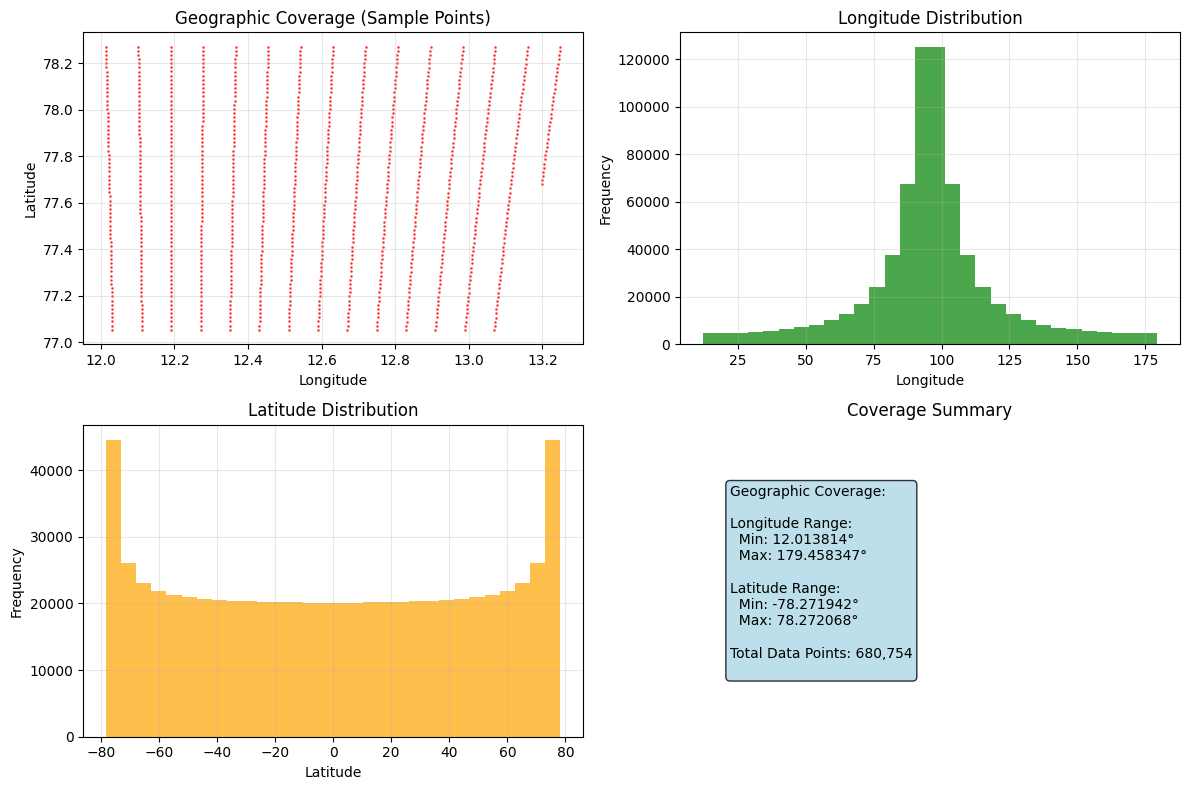

✅ Geographic visualization complete

🎯 Data structure understanding complete!


In [21]:
# Cell 3: Basic Visualization of NetCDF Data
print("🎨 BASIC DATA VISUALIZATION")
print("="*40)

# Find the most suitable variables for visualization
numeric_vars = []
for var_name, var_data in ds.data_vars.items():
    if np.issubdtype(var_data.dtype, np.number) and var_data.size > 0:
        numeric_vars.append((var_name, var_data))

if numeric_vars:
    # Take the first numeric variable for visualization
    main_var_name, main_var = numeric_vars[0]
    print(f"📊 Visualizing: {main_var_name}")
    print(f"   Shape: {main_var.shape}")
    print(f"   Dimensions: {main_var.dims}")
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'NetCDF Data Analysis: {main_var_name}', fontsize=16)
    
    # Get sample data for plotting
    sample_data = main_var.values.flatten()
    valid_data = sample_data[~np.isnan(sample_data)]
    
    if len(valid_data) > 0:
        # 1. Histogram
        axes[0,0].hist(valid_data, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        axes[0,0].set_title(f'{main_var_name} - Data Distribution')
        axes[0,0].set_xlabel(main_var_name)
        axes[0,0].set_ylabel('Frequency')
        axes[0,0].grid(True, alpha=0.3)
        
        # 2. Box plot
        axes[0,1].boxplot(valid_data[:10000])  # Limit for performance
        axes[0,1].set_title(f'{main_var_name} - Box Plot')
        axes[0,1].set_ylabel(main_var_name)
        axes[0,1].grid(True, alpha=0.3)
        
        # 3. Line plot of sample data
        sample_size = min(1000, len(valid_data))
        sample_indices = np.linspace(0, len(valid_data)-1, sample_size, dtype=int)
        axes[1,0].plot(valid_data[sample_indices], 'b-', linewidth=1)
        axes[1,0].set_title(f'{main_var_name} - Sample Data')
        axes[1,0].set_xlabel('Sample Index')
        axes[1,0].set_ylabel(main_var_name)
        axes[1,0].grid(True, alpha=0.3)
        
        # 4. Statistics summary
        stats_text = f"""Statistics for {main_var_name}:
        
Count: {len(valid_data):,}
Min: {np.min(valid_data):.6f}
Max: {np.max(valid_data):.6f}
Mean: {np.mean(valid_data):.6f}
Std: {np.std(valid_data):.6f}
Median: {np.median(valid_data):.6f}
        """
        
        axes[1,1].text(0.1, 0.5, stats_text, transform=axes[1,1].transAxes,
                     fontsize=10, verticalalignment='center',
                     bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
        axes[1,1].set_title('Statistics Summary')
        axes[1,1].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"✅ Visualization complete for {main_var_name}")
        
        # Show coordinate visualization if available
        if 'latitude' in ds.coords and 'longitude' in ds.coords:
            print(f"\n🗺️ COORDINATE VISUALIZATION")
            plt.figure(figsize=(12, 8))
            
            # Plot geographic coverage
            plt.subplot(2, 2, 1)
            plt.scatter(ds.longitude.values.flatten()[:1000], 
                       ds.latitude.values.flatten()[:1000], 
                       c='red', s=1, alpha=0.6)
            plt.xlabel('Longitude')
            plt.ylabel('Latitude')
            plt.title('Geographic Coverage (Sample Points)')
            plt.grid(True, alpha=0.3)
            
            # Longitude distribution
            plt.subplot(2, 2, 2)
            plt.hist(ds.longitude.values.flatten(), bins=30, alpha=0.7, color='green')
            plt.xlabel('Longitude')
            plt.ylabel('Frequency')
            plt.title('Longitude Distribution')
            plt.grid(True, alpha=0.3)
            
            # Latitude distribution  
            plt.subplot(2, 2, 3)
            plt.hist(ds.latitude.values.flatten(), bins=30, alpha=0.7, color='orange')
            plt.xlabel('Latitude')
            plt.ylabel('Frequency')
            plt.title('Latitude Distribution')
            plt.grid(True, alpha=0.3)
            
            # Data coverage info
            plt.subplot(2, 2, 4)
            coverage_text = f"""Geographic Coverage:
            
Longitude Range:
  Min: {ds.longitude.min().values:.6f}°
  Max: {ds.longitude.max().values:.6f}°
  
Latitude Range:
  Min: {ds.latitude.min().values:.6f}°
  Max: {ds.latitude.max().values:.6f}°
  
Total Data Points: {ds.longitude.size:,}
            """
            
            plt.text(0.1, 0.5, coverage_text, transform=plt.gca().transAxes,
                    fontsize=10, verticalalignment='center',
                    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
            plt.title('Coverage Summary')
            plt.axis('off')
            
            plt.tight_layout()
            plt.show()
            
            print("✅ Geographic visualization complete")
    
    else:
        print("❌ No valid data found for visualization")
else:
    print("❌ No numeric variables found for visualization")

print(f"\n🎯 Data structure understanding complete!")

In [22]:
# Cell 4: Enhanced Regional Slicing using SWOT-OpenToolkit Algorithms


# Add SWOT-OpenToolkit to path
toolkit_path = r"C:\Users\abhik\Desktop\project related work\SWOT-OpenToolkit\src"
if toolkit_path not in sys.path:
    sys.path.append(toolkit_path)

# Initialize variables to avoid unbound issues
swot: Optional[Any] = None
toolkit_available = False

try:
    import swot_ssh_utils as swot  # type: ignore
    toolkit_available = True
    print("✅ SWOT-OpenToolkit imported successfully!")
except ImportError:
    toolkit_available = False
    print("⚠️ SWOT-OpenToolkit not available, using standard xarray methods")

# Ensure the NetCDF dataset is loaded before running this cell
ds: Optional[xr.Dataset] = None
file_path: str = ""

try:
    _ = ds  # Check if ds exists (using _ to indicate intentional unused expression)
    if ds is None:
        raise NameError("ds is None")
except NameError:
    file_path = r"C:\Users\abhik\Desktop\project related work\SWOT_L2_LR_SSH_2.0_2.0-20250815_094335\SWOT_L2_LR_SSH_Basic_026_230_20250101T004209_20250101T013337_PIC2_01.nc"
    ds = xr.open_dataset(file_path)

# Define the region of interest (Andaman & Nicobar region)
lat_min = 8.0   # minimum latitude
lat_max = 14.0  # maximum latitude
lon_min = 92.0  # minimum longitude
lon_max = 94.0  # maximum longitude

print("🗺️ ENHANCED REGIONAL SLICING")
print("="*50)
print(f"Target Region: Latitude {lat_min}°-{lat_max}°, Longitude {lon_min}°-{lon_max}°")

if toolkit_available and swot is not None:
    print("\n🚀 Using SWOT-OpenToolkit Enhanced Methods")
    
    # Method 1: Using SWOT-OpenToolkit SSH_L2 class
    try:
        swot_data = swot.SSH_L2()  # type: ignore
        lat_bounds = [lat_min, lat_max]  # OpenToolkit format
        
        # Load data with automatic regional filtering
        swot_data.load_data(file_path, lat_bounds=lat_bounds)
        
        if hasattr(swot_data, 'Basic'):
            regional_data = swot_data.Basic
            print(f"✅ SWOT-OpenToolkit regional loading successful!")
            print(f"📊 Regional data shape: {regional_data.ssh_karin.shape}")
            
            # Extract coordinates and data
            lats = regional_data.latitude.values
            lons = regional_data.longitude.values
            
            # Additional longitude filtering (OpenToolkit only filters by latitude)
            lon_mask = (lons >= lon_min) & (lons <= lon_max)
            
            print(f"📍 Data points after latitude filtering: {lats.size}")
            print(f"📍 Data points after longitude filtering: {lon_mask.sum()}")
            
            # Show sample data from the region
            if hasattr(regional_data, 'ssh_karin'):
                ssh_data = regional_data.ssh_karin.values
                valid_ssh = ssh_data[~np.isnan(ssh_data)]
                
                print(f"\n📊 SSH Data Statistics in Region:")
                print(f"   • Valid data points: {len(valid_ssh):,}")
                print(f"   • SSH range: {valid_ssh.min():.3f} to {valid_ssh.max():.3f} m")
                print(f"   • SSH mean: {valid_ssh.mean():.3f} m")
                print(f"   • SSH std: {valid_ssh.std():.3f} m")
            
        else:
            print("❌ No Basic data found in SWOT-OpenToolkit loading")
            toolkit_available = False
            
    except Exception as e:
        print(f"❌ SWOT-OpenToolkit method failed: {str(e)}")
        toolkit_available = False

# Fallback to enhanced xarray method if toolkit fails
if not toolkit_available:
    print("\n🔄 Using Enhanced xarray Regional Slicing")
    
    # Find coordinate names automatically
    lat_coord: Optional[str] = None
    lon_coord: Optional[str] = None
    
    for coord_name in ds.coords:
        coord_str = str(coord_name)  # Convert to string to fix Hashable type issue
        if 'lat' in coord_str.lower():
            lat_coord = coord_str
        if 'lon' in coord_str.lower():
            lon_coord = coord_str
    
    print(f"Detected coordinates: {lat_coord}, {lon_coord}")
    
    if lat_coord and lon_coord:
        # Create comprehensive regional mask
        lat_mask = (ds[lat_coord] >= lat_min) & (ds[lat_coord] <= lat_max)
        lon_mask = (ds[lon_coord] >= lon_min) & (ds[lon_coord] <= lon_max)
        regional_mask = lat_mask & lon_mask
        
        # Apply regional slicing
        ds_region = ds.where(regional_mask, drop=True)
        
        print(f"\n📊 Regional Data Summary:")
        if regional_mask is not None:
            try:
                total_points = regional_mask.sum().values
                print(f"   • Total data points in region: {total_points}")
            except AttributeError:
                print(f"   • Could not calculate total data points in region (mask type issue)")
        else:
            print(f"   • Could not calculate total data points in region")
        
        # Get actual coordinate bounds in the region
        regional_lats = ds_region[lat_coord].values
        regional_lons = ds_region[lon_coord].values
        
        valid_lats = regional_lats[~np.isnan(regional_lats)]
        valid_lons = regional_lons[~np.isnan(regional_lons)]
        
        if len(valid_lats) > 0:
            print(f"   • Actual latitude range: {valid_lats.min():.3f}° to {valid_lats.max():.3f}°")
            print(f"   • Actual longitude range: {valid_lons.min():.3f}° to {valid_lons.max():.3f}°")
            
            # Analyze key variables in the region
            key_vars = ['ssh_karin', 'ssha_karin', 'ssh_karin_2', 'ssha_karin_2']
            
            print(f"\n📋 Key Variables in Region:")
            for var in key_vars:
                if var in ds_region.data_vars:
                    var_data = ds_region[var].values.flatten()
                    valid_data = var_data[~np.isnan(var_data)]
                    
                    if len(valid_data) > 0:
                        print(f"   • {var}:")
                        print(f"     - Valid points: {len(valid_data):,}")
                        print(f"     - Range: {valid_data.min():.4f} to {valid_data.max():.4f}")
                        print(f"     - Mean: {valid_data.mean():.4f} ± {valid_data.std():.4f}")
            
            # Create a clean regional DataFrame for further analysis
            print(f"\n📋 Creating Regional DataFrame:")
            
            # Convert to DataFrame with proper handling
            df_region = ds_region.to_dataframe()
            
            # Remove rows where all key variables are NaN
            key_columns = [col for col in key_vars if col in df_region.columns]
            if key_columns:
                df_clean = df_region.dropna(subset=key_columns, how='all').reset_index()
                
                if len(df_clean) > 0:
                    print(f"✅ Successfully created regional DataFrame with {len(df_clean):,} valid rows")
                    print(f"\nSample data from region:")
                    
                    # Show sample with key columns
                    display_cols = [lat_coord, lon_coord] + key_columns[:3]
                    display_cols = [col for col in display_cols if col in df_clean.columns]
                    
                    if display_cols:  # Check if we have columns to display
                        print(df_clean[display_cols].head(10))
                    else:
                        print("No display columns available")
                else:
                    print("❌ No valid data rows found in the region")
            else:
                print("❌ No key SSH variables found in dataset")
        else:
            print("❌ No valid coordinate data found in the region")

print(f"\n🎯 Regional slicing complete!")
print(f"💡 Tip: Use 'ds_region' variable for further analysis of the regional data")

⚠️ SWOT-OpenToolkit not available, using standard xarray methods
🗺️ ENHANCED REGIONAL SLICING
Target Region: Latitude 8.0°-14.0°, Longitude 92.0°-94.0°

🔄 Using Enhanced xarray Regional Slicing
Detected coordinates: latitude, longitude

📊 Regional Data Summary:
   • Total data points in region: 9691
   • Actual latitude range: 8.005° to 14.137°
   • Actual longitude range: 93.000° to 94.887°

📋 Key Variables in Region:
   • ssh_karin:
     - Valid points: 8,629
     - Range: -62.0190 to -48.0970
     - Mean: -56.6021 ± 3.3190
   • ssha_karin:
     - Valid points: 8,629
     - Range: -0.4036 to 1.2362
     - Mean: 0.6340 ± 0.2931
   • ssh_karin_2:
     - Valid points: 8,629
     - Range: -62.0200 to -48.0897
     - Mean: -56.6006 ± 3.3218
   • ssha_karin_2:
     - Valid points: 8,629
     - Range: -0.3990 to 1.2373
     - Mean: 0.6355 ± 0.2922

📋 Creating Regional DataFrame:
✅ Successfully created regional DataFrame with 17,258 valid rows

Sample data from region:
    latitude  longitud

🔍 ADVANCED REGIONAL ANALYSIS
✅ Using regional data from previous cell

🛡️ QUALITY CONTROL ANALYSIS
Available quality flags: ['ssh_karin_qual', 'ssha_karin_qual', 'ssh_karin_2_qual', 'ssha_karin_2_qual', 'ancillary_surface_classification_flag', 'dynamic_ice_flag', 'rain_flag', 'rad_surface_type_flag', 'height_cor_xover_qual']

📊 SSH Quality Flag Distribution:
   • Quality 0: 7,423 points (76.6%)
   • Quality 128: 7 points (0.1%)
   • Quality 144: 6 points (0.1%)
   • Quality 256: 1,177 points (12.1%)
   • Quality 384: 2 points (0.0%)
   • Quality 400: 13 points (0.1%)
   • Quality 1073774736: 1 points (0.0%)
   • Quality 2684354816: 1,062 points (11.0%)

🌊 Surface Classification in Region:
   • Open Ocean: 9,690 points (100.0%)
   • Coastal: 1 points (0.0%)

🎯 CREATING HIGH-QUALITY SUBSET
   • ssh_quality: 7,423 points pass
   • open_ocean: 9,690 points pass
   • Combined criteria: 7,423 high-quality points

📈 SSH STATISTICS COMPARISON

   SSH_KARIN:
     Original: 8,629 points, mean=-5

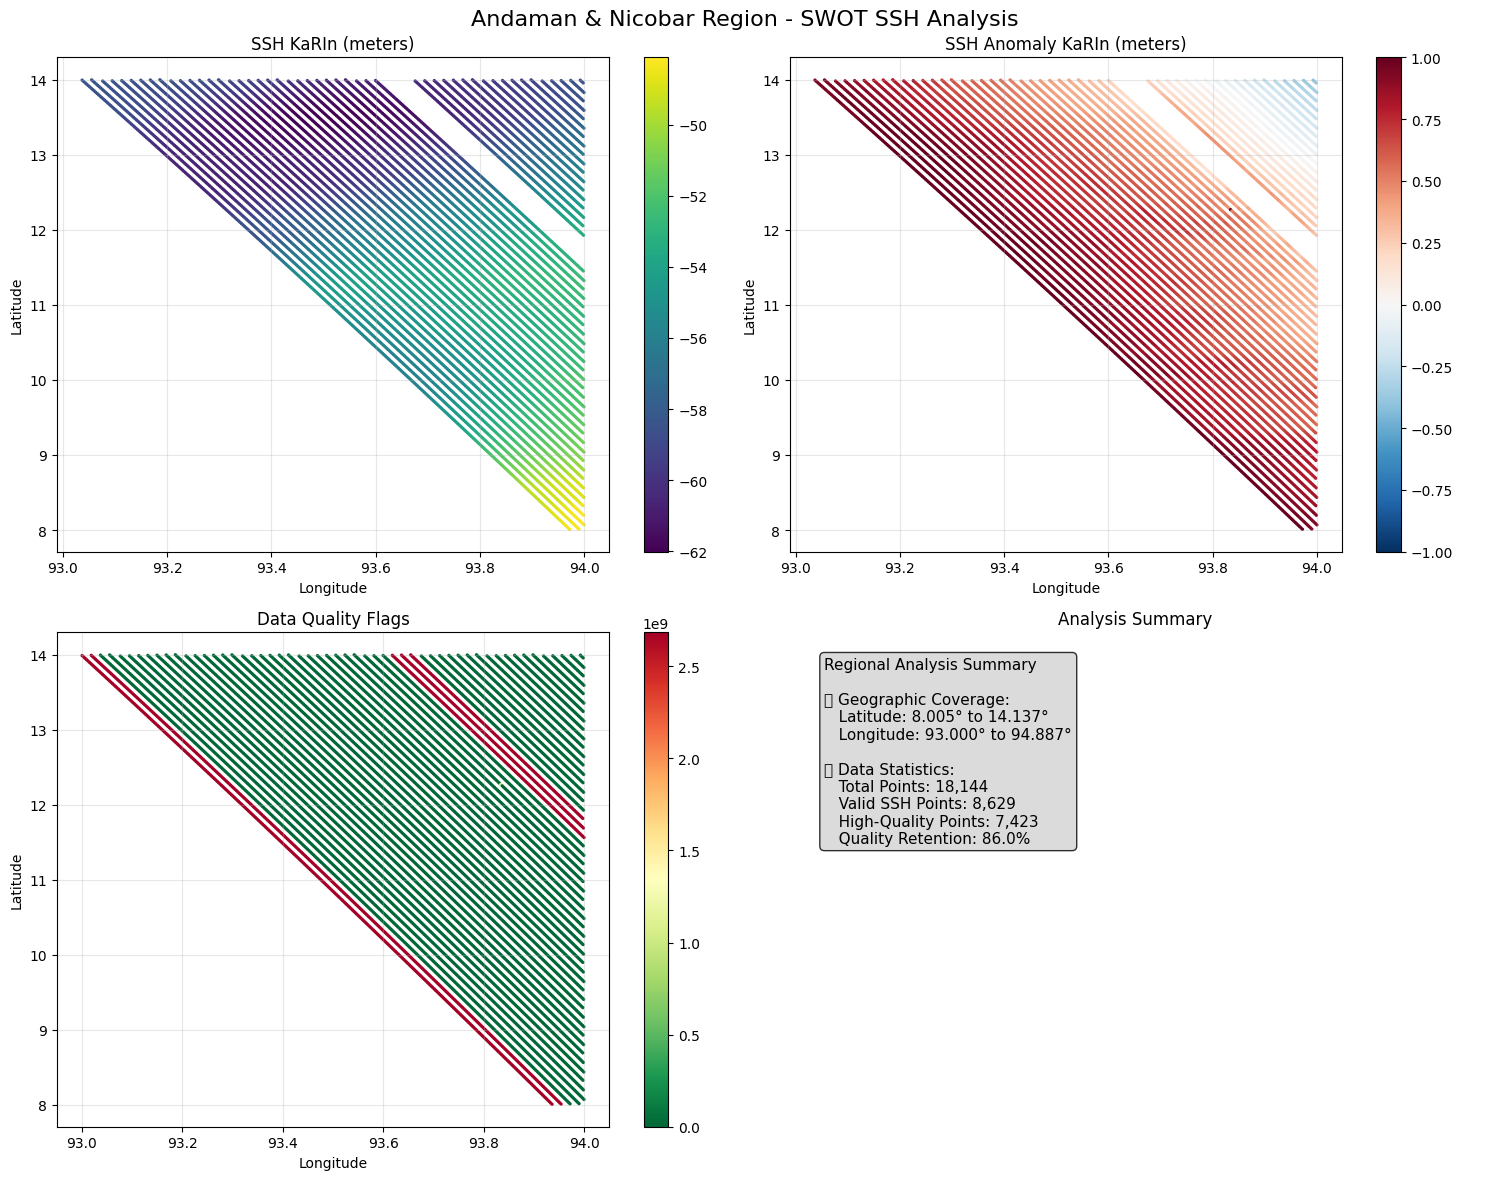

✅ Regional analysis complete!
💡 The high-quality dataset is available as 'ds_hq_region' for further analysis


In [23]:
# Cell 5: Advanced Regional Analysis and Quality Control
print("🔍 ADVANCED REGIONAL ANALYSIS")
print("="*50)

# Ensure we have the regional data from the previous cell
try:
    _ = ds_region  # Check if ds_region exists (using _ to indicate intentional unused expression)
    print("✅ Using regional data from previous cell")
except NameError:
    print("❌ Please run the previous cell first to create ds_region")
    
# Advanced quality control and analysis
if 'ds_region' in locals():
    # Quality control using SWOT flags
    print("\n🛡️ QUALITY CONTROL ANALYSIS")
    
    # Check available quality flags
    quality_flags = []
    for var in ds_region.data_vars:
        var_str = str(var)  # Convert to string to fix Hashable type issue
        if 'qual' in var_str or 'flag' in var_str:
            quality_flags.append(var_str)
    
    print(f"Available quality flags: {quality_flags}")
    
    # Analyze SSH data quality in the region
    if 'ssh_karin_qual' in ds_region.data_vars:
        ssh_qual = ds_region.ssh_karin_qual.values.flatten()
        unique_quals = np.unique(ssh_qual[~np.isnan(ssh_qual)])
        
        print(f"\n📊 SSH Quality Flag Distribution:")
        for qual in unique_quals:
            count = np.sum(ssh_qual == qual)
            percentage = (count / len(ssh_qual[~np.isnan(ssh_qual)])) * 100
            print(f"   • Quality {int(qual)}: {count:,} points ({percentage:.1f}%)")
    
    # Analyze surface classification
    if 'ancillary_surface_classification_flag' in ds_region.data_vars:
        surf_flag = ds_region.ancillary_surface_classification_flag.values.flatten()
        unique_flags = np.unique(surf_flag[~np.isnan(surf_flag)])
        
        print(f"\n🌊 Surface Classification in Region:")
        classification_map = {0: "Open Ocean", 1: "Coastal", 2: "Land", 3: "Continental Water"}
        
        for flag in unique_flags:
            count = np.sum(surf_flag == flag)
            percentage = (count / len(surf_flag[~np.isnan(surf_flag)])) * 100
            flag_name = classification_map.get(int(flag), f"Unknown({int(flag)})")
            print(f"   • {flag_name}: {count:,} points ({percentage:.1f}%)")
    
    # Create high-quality data subset (open ocean only)
    print(f"\n🎯 CREATING HIGH-QUALITY SUBSET")
    
    # Initialize variables to avoid unbound issues
    orig_valid: np.ndarray = np.array([])
    total_hq_points: int = 0
    
    # Define quality criteria
    quality_criteria = {}
    
    if 'ssh_karin_qual' in ds_region.data_vars:
        quality_criteria['ssh_quality'] = ds_region.ssh_karin_qual == 0
    
    if 'ancillary_surface_classification_flag' in ds_region.data_vars:
        quality_criteria['open_ocean'] = ds_region.ancillary_surface_classification_flag == 0
    
    # Apply quality filters
    if quality_criteria:
        # Combine all quality criteria
        combined_mask = None
        for criterion_name, mask in quality_criteria.items():
            if combined_mask is None:
                combined_mask = mask
            else:
                combined_mask = combined_mask & mask
            
            try:
                points_passing = mask.sum().values if hasattr(mask, 'sum') else 0
                print(f"   • {criterion_name}: {points_passing:,} points pass")
            except AttributeError:
                print(f"   • {criterion_name}: Unable to calculate passing points")
        
        # Create high-quality regional dataset
        if combined_mask is not None:
            ds_hq_region = ds_region.where(combined_mask, drop=True)
            try:
                total_hq_points = combined_mask.sum().values if hasattr(combined_mask, 'sum') else 0
            except AttributeError:
                total_hq_points = 0
        else:
            ds_hq_region = ds_region
            total_hq_points = 0
        
        print(f"   • Combined criteria: {total_hq_points:,} high-quality points")
        
        # Compare SSH statistics before and after quality control
        print(f"\n📈 SSH STATISTICS COMPARISON")
        
        for ssh_var in ['ssh_karin', 'ssha_karin']:
            if ssh_var in ds_region.data_vars:
                # Original data
                orig_data = ds_region[ssh_var].values.flatten()
                orig_valid = orig_data[~np.isnan(orig_data)]
                
                # High-quality data
                hq_data = ds_hq_region[ssh_var].values.flatten()
                hq_valid = hq_data[~np.isnan(hq_data)]
                
                print(f"\n   {ssh_var.upper()}:")
                print(f"     Original: {len(orig_valid):,} points, mean={orig_valid.mean():.4f}m, std={orig_valid.std():.4f}m")
                print(f"     High-Quality: {len(hq_valid):,} points, mean={hq_valid.mean():.4f}m, std={hq_valid.std():.4f}m")
                print(f"     Improvement: {((len(hq_valid)/len(orig_valid))*100):.1f}% data retained")
                
                # Update orig_valid for summary text (use the first variable's data)
                if ssh_var == 'ssh_karin':
                    # Store for use in summary text later
                    globals()['orig_valid_for_summary'] = orig_valid
    
    # Visualization of the regional data
    print(f"\n🎨 CREATING REGIONAL VISUALIZATION")
    
    # Create comprehensive regional plot
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Andaman & Nicobar Region - SWOT SSH Analysis', fontsize=16)
    
    # Get coordinates for plotting
    lats = ds_region.latitude.values.flatten()
    lons = ds_region.longitude.values.flatten()
    
    # Plot 1: SSH Karin
    if 'ssh_karin' in ds_region.data_vars:
        ssh_data = ds_region.ssh_karin.values.flatten()
        valid_mask = ~np.isnan(ssh_data) & ~np.isnan(lats) & ~np.isnan(lons)
        
        scatter1 = axes[0,0].scatter(lons[valid_mask], lats[valid_mask], 
                                   c=ssh_data[valid_mask], s=2, cmap='viridis')
        axes[0,0].set_title('SSH KaRIn (meters)')
        axes[0,0].set_xlabel('Longitude')
        axes[0,0].set_ylabel('Latitude')
        plt.colorbar(scatter1, ax=axes[0,0])
        axes[0,0].grid(True, alpha=0.3)
    
    # Plot 2: SSHA Karin
    if 'ssha_karin' in ds_region.data_vars:
        ssha_data = ds_region.ssha_karin.values.flatten()
        valid_mask = ~np.isnan(ssha_data) & ~np.isnan(lats) & ~np.isnan(lons)
        
        scatter2 = axes[0,1].scatter(lons[valid_mask], lats[valid_mask], 
                                   c=ssha_data[valid_mask], s=2, cmap='RdBu_r', 
                                   vmin=-1, vmax=1)
        axes[0,1].set_title('SSH Anomaly KaRIn (meters)')
        axes[0,1].set_xlabel('Longitude')
        axes[0,1].set_ylabel('Latitude')
        plt.colorbar(scatter2, ax=axes[0,1])
        axes[0,1].grid(True, alpha=0.3)
    
    # Plot 3: Data Quality Distribution
    if 'ssh_karin_qual' in ds_region.data_vars:
        qual_data = ds_region.ssh_karin_qual.values.flatten()
        valid_mask = ~np.isnan(qual_data) & ~np.isnan(lats) & ~np.isnan(lons)
        
        scatter3 = axes[1,0].scatter(lons[valid_mask], lats[valid_mask], 
                                   c=qual_data[valid_mask], s=2, cmap='RdYlGn_r')
        axes[1,0].set_title('Data Quality Flags')
        axes[1,0].set_xlabel('Longitude')
        axes[1,0].set_ylabel('Latitude')
        plt.colorbar(scatter3, ax=axes[1,0])
        axes[1,0].grid(True, alpha=0.3)
    
    # Plot 4: Statistical Summary
    summary_text = f"""Regional Analysis Summary
    
📍 Geographic Coverage:
   Latitude: {lats[~np.isnan(lats)].min():.3f}° to {lats[~np.isnan(lats)].max():.3f}°
   Longitude: {lons[~np.isnan(lons)].min():.3f}° to {lons[~np.isnan(lons)].max():.3f}°

📊 Data Statistics:
   Total Points: {len(lats):,}"""
   
    # Add SSH statistics if available
    if 'orig_valid_for_summary' in globals():
        summary_text += f"\n   Valid SSH Points: {len(globals()['orig_valid_for_summary']):,}"
    
    if 'quality_criteria' in locals() and quality_criteria:
        summary_text += f"\n   High-Quality Points: {total_hq_points:,}"
        if 'orig_valid_for_summary' in globals():
            summary_text += f"\n   Quality Retention: {((total_hq_points/len(globals()['orig_valid_for_summary']))*100):.1f}%"
    
    axes[1,1].text(0.05, 0.95, summary_text, transform=axes[1,1].transAxes,
                  fontsize=11, verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    axes[1,1].set_title('Analysis Summary')
    axes[1,1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Regional analysis complete!")
    print("💡 The high-quality dataset is available as 'ds_hq_region' for further analysis")

else:
    print("❌ No regional data available. Please run the previous cell first.")

🛰️ SWOT TEMPORAL ANALYSIS - ALONG-TRACK PROGRESSION
✅ Using regional datasets from previous analysis

📊 SWOT DATA STRUCTURE FOR TEMPORAL ANALYSIS
Available dimensions: ['num_lines', 'num_pixels', 'num_sides']
Data shape: FrozenMappingWarningOnValuesAccess({'num_lines': 336, 'num_pixels': 54, 'num_sides': 2})
SSH data shape: (336, 54)
SSH dimensions: ('num_lines', 'num_pixels')
Analyzing file: SWOT_L2_LR_SSH_Basic_026_230_20250101T004209_20250101T013337_PIC2_01.nc
🕐 Satellite Pass Time:
   Start: 2025-01-01 00:42:09 UTC
   End: 2025-01-01 01:33:37 UTC
   Duration: 3088 seconds

🌊 ALONG-TRACK SSH/SSHA TEMPORAL EVOLUTION
   Along-track points: 336
   Cross-track points: 54


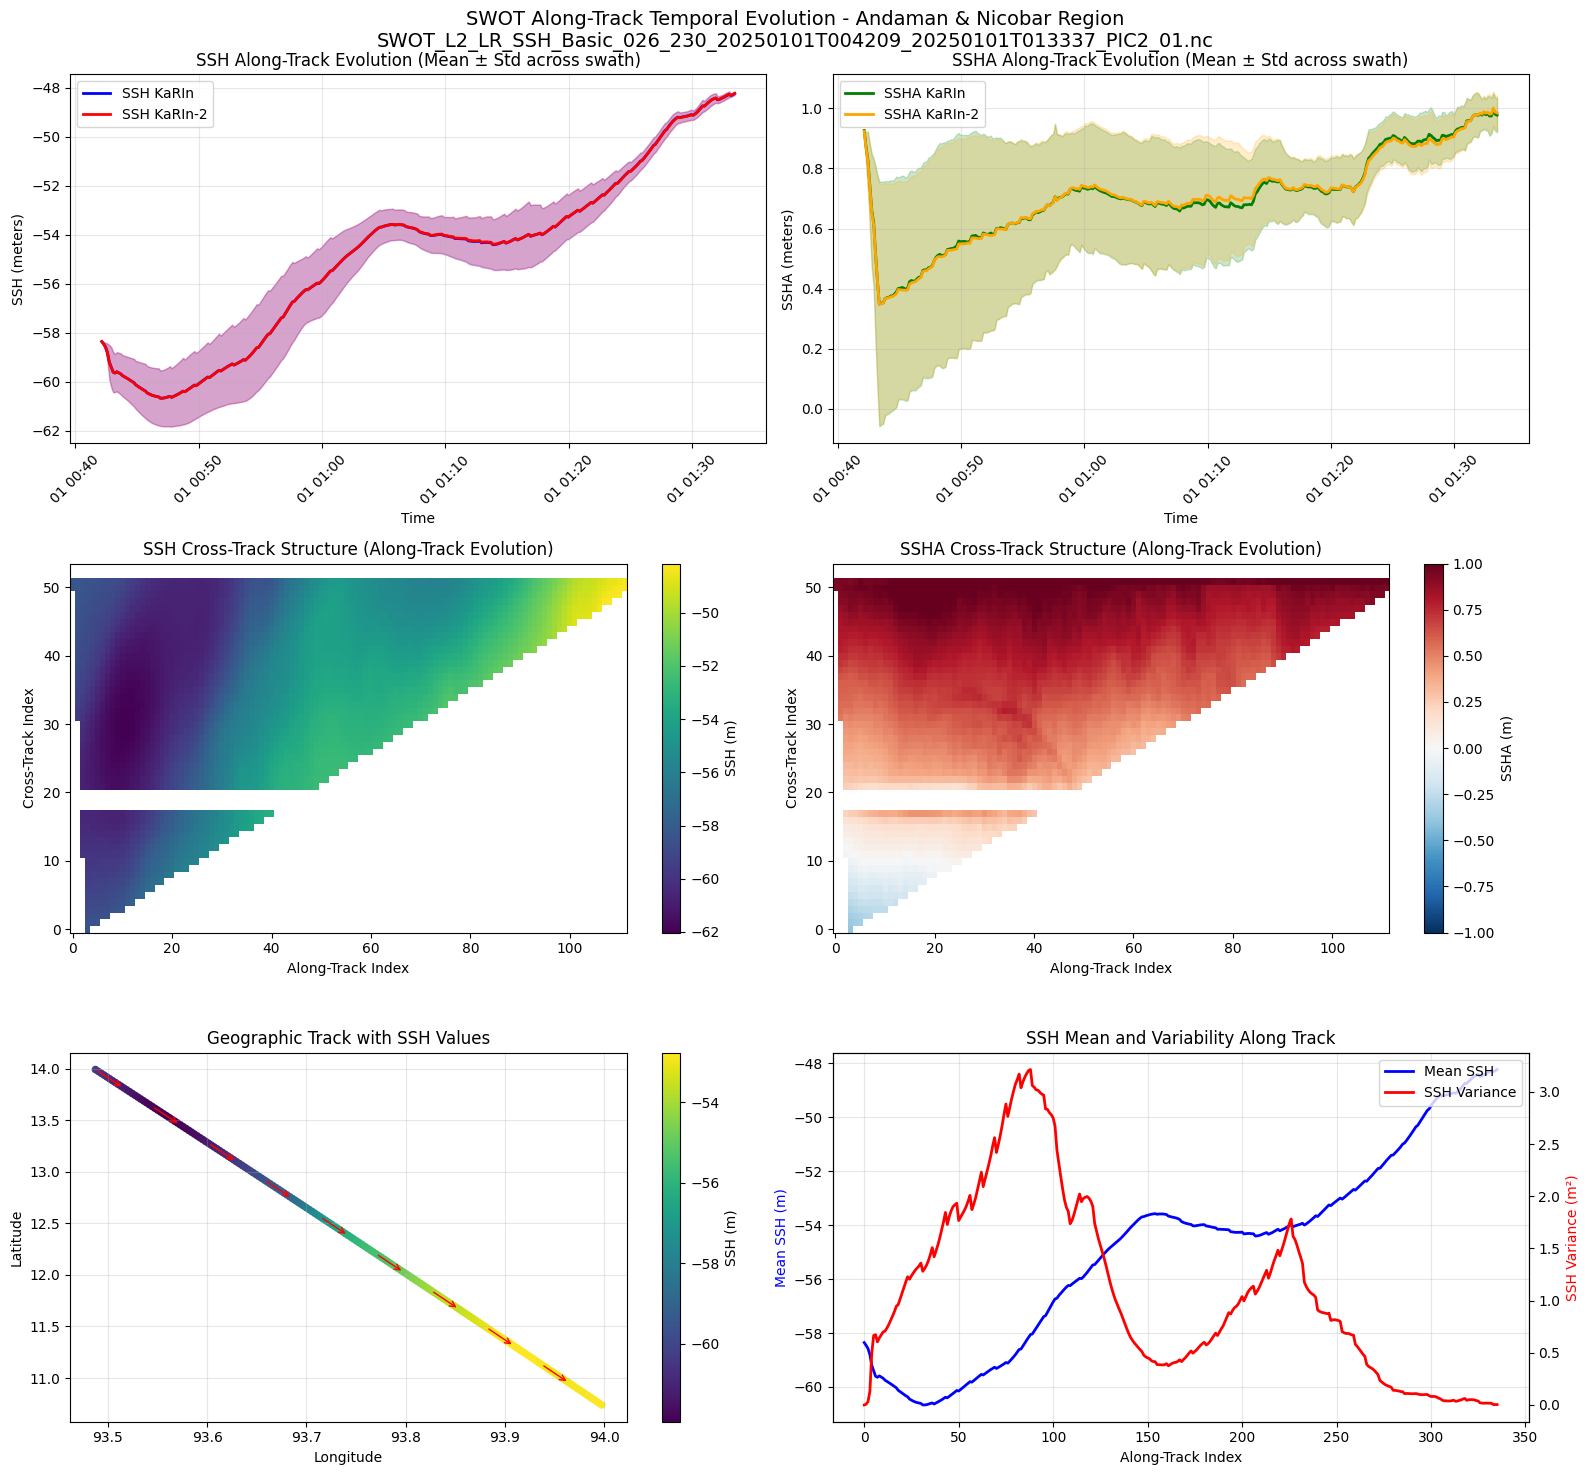


📈 ALONG-TRACK STATISTICAL ANALYSIS

SSH_KARIN Along-Track Analysis:
   • Valid along-track points: 336
   • Along-track mean: -54.8951 m
   • Along-track variability: 3.5616 m
   • Min along-track value: -60.6669 m
   • Max along-track value: -48.2270 m
   • Cross-track variability: 0.9501 m
   • scipy not available for trend analysis

SSHA_KARIN Along-Track Analysis:
   • Valid along-track points: 336
   • Along-track mean: 0.7037 m
   • Along-track variability: 0.1452 m
   • Min along-track value: 0.3485 m
   • Max along-track value: 0.9940 m
   • Cross-track variability: 0.4027 m
   • scipy not available for trend analysis

SSH_KARIN_2 Along-Track Analysis:
   • Valid along-track points: 336
   • Along-track mean: -54.8937 m
   • Along-track variability: 3.5620 m
   • Min along-track value: -60.6702 m
   • Max along-track value: -48.2195 m
   • Cross-track variability: 0.9489 m
   • scipy not available for trend analysis

SSHA_KARIN_2 Along-Track Analysis:
   • Valid along-track po

In [24]:
# Cell 6: SWOT Temporal Analysis - SSH/SSHA Along-Track Evolution
print("🛰️ SWOT TEMPORAL ANALYSIS - ALONG-TRACK PROGRESSION")
print("="*65)

# Ensure we have regional data from previous cells
try:
    _ = ds_region  # Check if ds_region exists
    _ = ds_hq_region  # Check if ds_hq_region exists
    print("✅ Using regional datasets from previous analysis")
except NameError:
    print("❌ Please run previous cells first to create regional datasets")
    
if 'ds_region' in locals():
    # SWOT-specific temporal analysis using along-track progression
    print(f"\n📊 SWOT DATA STRUCTURE FOR TEMPORAL ANALYSIS")
    
    # Check available dimensions (SWOT uses along-track x cross-track structure)
    print(f"Available dimensions: {list(ds_region.dims.keys())}")
    print(f"Data shape: {ds_region.dims}")
    
    # Get the actual data structure
    if 'ssh_karin' in ds_region.data_vars:
        ssh_shape = ds_region.ssh_karin.shape
        ssh_dims = ds_region.ssh_karin.dims
        print(f"SSH data shape: {ssh_shape}")
        print(f"SSH dimensions: {ssh_dims}")
        
        # Extract time information from filename (SWOT standard)
        import re
        from datetime import datetime
        
        # Initialize time variables to avoid unbound issues
        start_time: Optional[datetime] = None
        end_time: Optional[datetime] = None
        time_match = None
        
        # Extract time from filename
        filename = file_path.split('\\')[-1]
        print(f"Analyzing file: {filename}")
        
        # Parse SWOT filename for time info
        time_pattern = r'(\d{8}T\d{6})_(\d{8}T\d{6})'
        time_match = re.search(time_pattern, filename)
        
        if time_match:
            start_time_str = time_match.group(1)
            end_time_str = time_match.group(2)
            
            start_time = datetime.strptime(start_time_str, '%Y%m%dT%H%M%S')
            end_time = datetime.strptime(end_time_str, '%Y%m%dT%H%M%S')
            
            print(f"🕐 Satellite Pass Time:")
            print(f"   Start: {start_time.strftime('%Y-%m-%d %H:%M:%S UTC')}")
            print(f"   End: {end_time.strftime('%Y-%m-%d %H:%M:%S UTC')}")
            print(f"   Duration: {(end_time - start_time).total_seconds():.0f} seconds")
        
        # Create along-track temporal analysis
        print(f"\n🌊 ALONG-TRACK SSH/SSHA TEMPORAL EVOLUTION")
        
        # Get coordinate data
        lats = ds_region.latitude.values
        lons = ds_region.longitude.values
        
        # For SWOT, time is represented as along-track progression
        if len(ssh_shape) == 2:  # (along_track, cross_track)
            along_track_dim = ssh_shape[0]
            cross_track_dim = ssh_shape[1]
            
            print(f"   Along-track points: {along_track_dim}")
            print(f"   Cross-track points: {cross_track_dim}")
            
            # Create synthetic time array based on along-track progression
            time_array = []
            if time_match and start_time is not None and end_time is not None:
                total_seconds = (end_time - start_time).total_seconds()
                time_per_point = total_seconds / along_track_dim
                time_array = [start_time + pd.Timedelta(seconds=i*time_per_point) 
                             for i in range(along_track_dim)]
            else:
                # Create relative time array
                time_array = list(range(along_track_dim))
            
            # Initialize step variables for subsampling
            along_step = 1
            cross_step = 1
            
            # Create comprehensive temporal visualization
            fig, axes = plt.subplots(3, 2, figsize=(16, 15))
            fig.suptitle(f'SWOT Along-Track Temporal Evolution - Andaman & Nicobar Region\n{filename}', fontsize=14)
            
            # Prepare SSH and SSHA data for analysis
            ssh_vars = {'ssh_karin': 'SSH KaRIn', 'ssha_karin': 'SSHA KaRIn', 
                       'ssh_karin_2': 'SSH KaRIn-2', 'ssha_karin_2': 'SSHA KaRIn-2'}
            
            colors = ['blue', 'red', 'green', 'orange']
            
            # Plot 1: SSH Along-Track Evolution (Mean across swath)
            ax1 = axes[0, 0]
            for i, (var_name, var_label) in enumerate([('ssh_karin', 'SSH KaRIn'), ('ssh_karin_2', 'SSH KaRIn-2')]):
                if var_name in ds_region.data_vars:
                    ssh_data = ds_region[var_name].values
                    
                    # Calculate mean and std across swath for each along-track point
                    ssh_mean_along = np.nanmean(ssh_data, axis=1)
                    ssh_std_along = np.nanstd(ssh_data, axis=1)
                    
                    valid_indices = ~np.isnan(ssh_mean_along)
                    
                    if np.any(valid_indices):
                        if time_match:
                            time_valid = [time_array[j] for j in range(len(time_array)) if valid_indices[j]]
                            ax1.plot(time_valid, ssh_mean_along[valid_indices], 
                                   color=colors[i], label=var_label, linewidth=2)
                            ax1.fill_between(time_valid, 
                                           ssh_mean_along[valid_indices] - ssh_std_along[valid_indices], 
                                           ssh_mean_along[valid_indices] + ssh_std_along[valid_indices], 
                                           color=colors[i], alpha=0.2)
                        else:
                            ax1.plot(ssh_mean_along[valid_indices], color=colors[i], 
                                   label=var_label, linewidth=2)
                            ax1.fill_between(range(len(ssh_mean_along[valid_indices])), 
                                           ssh_mean_along[valid_indices] - ssh_std_along[valid_indices], 
                                           ssh_mean_along[valid_indices] + ssh_std_along[valid_indices], 
                                           color=colors[i], alpha=0.2)
            
            ax1.set_title('SSH Along-Track Evolution (Mean ± Std across swath)')
            ax1.set_xlabel('Time' if time_match else 'Along-track Index')
            ax1.set_ylabel('SSH (meters)')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
            if time_match:
                plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
            
            # Plot 2: SSHA Along-Track Evolution
            ax2 = axes[0, 1]
            for i, (var_name, var_label) in enumerate([('ssha_karin', 'SSHA KaRIn'), ('ssha_karin_2', 'SSHA KaRIn-2')]):
                if var_name in ds_region.data_vars:
                    ssha_data = ds_region[var_name].values
                    
                    ssha_mean_along = np.nanmean(ssha_data, axis=1)
                    ssha_std_along = np.nanstd(ssha_data, axis=1)
                    
                    valid_indices = ~np.isnan(ssha_mean_along)
                    
                    if np.any(valid_indices):
                        if time_match:
                            time_valid = [time_array[j] for j in range(len(time_array)) if valid_indices[j]]
                            ax2.plot(time_valid, ssha_mean_along[valid_indices], 
                                   color=colors[i+2], label=var_label, linewidth=2)
                            ax2.fill_between(time_valid, 
                                           ssha_mean_along[valid_indices] - ssha_std_along[valid_indices], 
                                           ssha_mean_along[valid_indices] + ssha_std_along[valid_indices], 
                                           color=colors[i+2], alpha=0.2)
                        else:
                            ax2.plot(ssha_mean_along[valid_indices], color=colors[i+2], 
                                   label=var_label, linewidth=2)
                            ax2.fill_between(range(len(ssha_mean_along[valid_indices])), 
                                           ssha_mean_along[valid_indices] - ssha_std_along[valid_indices], 
                                           ssha_mean_along[valid_indices] + ssha_std_along[valid_indices], 
                                           color=colors[i+2], alpha=0.2)
            
            ax2.set_title('SSHA Along-Track Evolution (Mean ± Std across swath)')
            ax2.set_xlabel('Time' if time_match else 'Along-track Index')
            ax2.set_ylabel('SSHA (meters)')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
            if time_match:
                plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
            
            # Plot 3: SSH Cross-track Structure over Along-track Distance
            ax3 = axes[1, 0]
            if 'ssh_karin' in ds_region.data_vars:
                ssh_data = ds_region['ssh_karin'].values
                
                # Subsample for visualization if data is too large
                max_along_points = 100
                max_cross_points = 50
                
                along_step = max(1, along_track_dim // max_along_points)
                cross_step = max(1, cross_track_dim // max_cross_points)
                
                ssh_subset = ssh_data[::along_step, ::cross_step]
                
                im3 = ax3.imshow(ssh_subset.T, aspect='auto', cmap='viridis', 
                               origin='lower', interpolation='nearest')
                
                ax3.set_title('SSH Cross-Track Structure (Along-Track Evolution)')
                ax3.set_xlabel('Along-Track Index')
                ax3.set_ylabel('Cross-Track Index')
                plt.colorbar(im3, ax=ax3, label='SSH (m)')
            
            # Plot 4: SSHA Cross-track Structure
            ax4 = axes[1, 1]
            if 'ssha_karin' in ds_region.data_vars:
                ssha_data = ds_region['ssha_karin'].values
                ssha_subset = ssha_data[::along_step, ::cross_step]
                
                im4 = ax4.imshow(ssha_subset.T, aspect='auto', cmap='RdBu_r', 
                               origin='lower', interpolation='nearest',
                               vmin=-1, vmax=1)
                
                ax4.set_title('SSHA Cross-Track Structure (Along-Track Evolution)')
                ax4.set_xlabel('Along-Track Index')
                ax4.set_ylabel('Cross-Track Index')
                plt.colorbar(im4, ax=ax4, label='SSHA (m)')
            
            # Plot 5: Geographic Track with SSH Values
            ax5 = axes[2, 0]
            if 'ssh_karin' in ds_region.data_vars:
                # Use center swath for geographic track
                center_track = cross_track_dim // 2
                
                lats_track = lats[:, center_track]
                lons_track = lons[:, center_track]
                ssh_track = ds_region['ssh_karin'].values[:, center_track]
                
                valid_track = ~(np.isnan(lats_track) | np.isnan(lons_track) | np.isnan(ssh_track))
                
                if np.any(valid_track):
                    scatter5 = ax5.scatter(lons_track[valid_track], lats_track[valid_track], 
                                         c=ssh_track[valid_track], s=20, cmap='viridis')
                    
                    # Add arrows to show direction of travel
                    for i in range(0, len(lons_track[valid_track])-10, 20):
                        if i+10 < len(lons_track[valid_track]):
                            ax5.annotate('', xy=(lons_track[valid_track][i+10], lats_track[valid_track][i+10]), 
                                       xytext=(lons_track[valid_track][i], lats_track[valid_track][i]),
                                       arrowprops=dict(arrowstyle='->', color='red', lw=1))
                    
                    ax5.set_title('Geographic Track with SSH Values')
                    ax5.set_xlabel('Longitude')
                    ax5.set_ylabel('Latitude')
                    plt.colorbar(scatter5, ax=ax5, label='SSH (m)')
                    ax5.grid(True, alpha=0.3)
            
            # Plot 6: SSH Variability Analysis
            ax6 = axes[2, 1]
            if 'ssh_karin' in ds_region.data_vars:
                ssh_data = ds_region['ssh_karin'].values
                
                # Calculate along-track variability metrics
                ssh_variance_along = np.nanvar(ssh_data, axis=1)  # Variance across swath
                ssh_mean_along = np.nanmean(ssh_data, axis=1)     # Mean across swath
                
                valid_var = ~np.isnan(ssh_variance_along)
                
                # Create twin axis for variance
                ax6_twin = ax6.twinx()
                
                line1 = ax6.plot(ssh_mean_along[valid_var], 'b-', linewidth=2, label='Mean SSH')
                line2 = ax6_twin.plot(ssh_variance_along[valid_var], 'r-', linewidth=2, label='SSH Variance')
                
                ax6.set_xlabel('Along-Track Index')
                ax6.set_ylabel('Mean SSH (m)', color='b')
                ax6_twin.set_ylabel('SSH Variance (m²)', color='r')
                ax6.set_title('SSH Mean and Variability Along Track')
                
                # Combine legends
                lines = line1 + line2
                labels = [l.get_label() for l in lines]
                ax6.legend(lines, labels, loc='upper right')
                
                ax6.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            # Statistical Analysis
            print(f"\n📈 ALONG-TRACK STATISTICAL ANALYSIS")
            print(f"{'='*55}")
            
            for var_name in ['ssh_karin', 'ssha_karin', 'ssh_karin_2', 'ssha_karin_2']:
                if var_name in ds_region.data_vars:
                    data = ds_region[var_name].values
                    
                    # Along-track statistics
                    along_track_means = np.nanmean(data, axis=1)
                    along_track_stds = np.nanstd(data, axis=1)
                    
                    valid_along = ~np.isnan(along_track_means)
                    
                    if np.any(valid_along):
                        print(f"\n{var_name.upper()} Along-Track Analysis:")
                        print(f"   • Valid along-track points: {np.sum(valid_along)}")
                        print(f"   • Along-track mean: {np.nanmean(along_track_means):.4f} m")
                        print(f"   • Along-track variability: {np.nanstd(along_track_means):.4f} m")
                        print(f"   • Min along-track value: {np.nanmin(along_track_means):.4f} m")
                        print(f"   • Max along-track value: {np.nanmax(along_track_means):.4f} m")
                        
                        # Cross-track statistics
                        cross_track_means = np.nanmean(data, axis=0)
                        print(f"   • Cross-track variability: {np.nanstd(cross_track_means):.4f} m")
                        
                        # Calculate trend along track if enough points
                        if np.sum(valid_along) > 10:
                            try:
                                from scipy import stats
                                from scipy.stats._result_classes import LinregressResult  # Import for type checking
                                trend_indices = np.arange(len(along_track_means))[valid_along]
                                trend_values = along_track_means[valid_along]
                                
                                # Ensure we have arrays, not tuples
                                trend_indices = np.asarray(trend_indices, dtype=float)
                                trend_values = np.asarray(trend_values, dtype=float)
                                
                                result: LinregressResult = stats.linregress(trend_indices, trend_values)
                                slope = float(result.slope)
                                r_value = float(result.rvalue)
                                p_value = float(result.pvalue)
                                
                                print(f"   • Along-track trend: {slope:.6f} m/point")
                                print(f"   • Trend significance: R²={r_value**2:.3f}, p={p_value:.3f}")
                                
                                if p_value < 0.05:
                                    trend_dir = "increasing" if slope > 0 else "decreasing"
                                    print(f"   • Significant {trend_dir} trend detected!")
                            except ImportError:
                                print(f"   • scipy not available for trend analysis")
                            except Exception as e:
                                print(f"   • Trend analysis failed: {str(e)}")
            
            # Quality analysis along track
            if 'ssh_karin_qual' in ds_region.data_vars:
                print(f"\n🛡️ QUALITY ANALYSIS ALONG TRACK")
                qual_data = ds_region['ssh_karin_qual'].values
                
                # Calculate quality percentage for each along-track point
                quality_along = []
                for i in range(qual_data.shape[0]):
                    track_qual = qual_data[i, :]
                    valid_qual = track_qual[~np.isnan(track_qual)]
                    if len(valid_qual) > 0:
                        high_quality = np.sum(valid_qual == 0)
                        quality_pct = (high_quality / len(valid_qual)) * 100
                        quality_along.append(quality_pct)
                    else:
                        quality_along.append(np.nan)
                
                quality_along = np.array(quality_along)
                valid_quality = ~np.isnan(quality_along)
                
                if np.any(valid_quality):
                    print(f"   • Mean data quality along track: {np.nanmean(quality_along):.1f}%")
                    print(f"   • Quality variability: {np.nanstd(quality_along):.1f}%")
                    print(f"   • Best quality section: {np.nanmax(quality_along):.1f}%")
                    print(f"   • Worst quality section: {np.nanmin(quality_along):.1f}%")
            
            print(f"\n✅ SWOT temporal analysis complete!")
            print(f"💡 This shows SSH/SSHA evolution as satellite travels through your region")
            print(f"📊 Use the high-quality regional data for oceanographic feature analysis")
        
        else:
            print(f"❌ Unexpected data shape: {ssh_shape}")
            print(f"Expected 2D array (along_track, cross_track)")
    
    else:
        print("❌ No SSH data found for temporal analysis")

else:
    print("❌ Regional dataset not available. Please run previous cells first.")